In [1]:
from idlelib.configdialog import font_sample_text

import requests
from IPython.terminal.shortcuts.auto_suggest import accept
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import json
import time
import os
import copy

from h5py.h5a import delete
from torchmetrics.functional import specificity
from tqdm import tqdm  # 用于显示进度条
import matplotlib.pyplot as plt


C:\Users\admin\.conda\envs\Enzyme_design\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ================= 配置区域 =================
# 核心查询：GT1家族 (PF00201) + 植物界 (33090)
# 注意：这里不限制 reviewed:true，因为我们需要那 65k 数据做预训练，但在代码里会标记数据质量
QUERY = 'PF00201 AND taxonomy_id:33090'
# API 地址
BASE_URL = "https://rest.uniprot.org/uniprotkb/stream"
save_path = r'E:\pUGTdb\20251128_collection\download_PF00201_taxonomy33090\download_data'

In [152]:
# ================= 解析辅助函数 =================
def parse_kinetics_text(text):
    """
    从非结构化的 note 文本中尝试提取 kcat 和 efficiency。
    UniProt 的 kcat 经常藏在类似 "kcat is 10.5 s(-1)" 的文本里。
    """
    results = {'kcat': [], 'efficiency': []}
    if not text:
        return results
    
    # 提取 kcat
    # 匹配模式: kcat is 12.5 s(-1) with substrate
    kcat_matches = re.findall(r'kcat\s*(?:is|=)\s*([\d\.]+)\s*([a-zA-Z0-9\(\)\-\/]+)(?:\s+with\s+(.*?)(?:\s+as substrate|\.|$))?', text, re.IGNORECASE)
    for val, unit, sub in kcat_matches:
        results['kcat'].append({
            'value': val,
            'unit': unit,
            'substrate': sub.strip() if sub else "Unspecified"
        })

    return results

def extract_biophysicochemical(comments):
    """
    深度挖掘 'Biophysicochemical properties' 类型的注释。
    包括: Km, Vmax, pH, Temperature
    """
    data = {
        'km': [],
        'vmax': [],
        'kcat': [], # 来自 structured data 或 text note
        'ph_optimum': None,
        'ph_range': None,
        'temp_optimum': None,
        'temp_range': None
    }
    
    for c in comments:
        if c.get('commentType') != 'BIOPHYSICOCHEMICAL PROPERTIES':
            continue
            
        # 1. 动力学参数 (Kinetic Parameters)
        kp = c.get('kineticParameters', {})
        
        # 提取 Km
        if 'michaelisConstants' in kp:
            for item in kp['michaelisConstants']:
                data['km'].append({
                    'substrate': item.get('substrate'),
                    'value': item.get('constant'),
                    'unit': item.get('unit')
                })
        
        # 提取 Vmax
        if 'maximumVelocities' in kp:
            for item in kp['maximumVelocities']:
                data['vmax'].append({
                    'enzyme_text': item.get('enzyme'),
                    'value': item.get('velocity'),
                    'unit': item.get('unit')
                })

        # 提取 kcat (通常在 note 中)
        if 'note' in kp:
            for t in kp['note'].get('texts', []):
                extracted = parse_kinetics_text(t.get('value', ''))
                data['kcat'].extend(extracted['kcat'])

        # 2. pH 依赖性
        if 'phDependence' in c:
            texts = c['phDependence'].get('texts', [])
            if texts:
                text_val = texts[0].get('value')
                data['ph_optimum'] = text_val # 简单存储全文，后续可做正则提取数值
                
        # 3. 温度 依赖性
        if 'temperatureDependence' in c:
            texts = c['temperatureDependence'].get('texts', [])
            if texts:
                text_val = texts[0].get('value')
                data['temp_optimum'] = text_val

    return data

def extract_features(features):
    """
    提取活性位点和结合位点，保留结合位点的描述（如 UDP-glucose binding）
    """
    active_sites = []
    binding_sites = []
    
    for f in features:
        f_type = f.get('type')
        location = f.get('location', {}).get('start', {}).get('value')
        description = f.get('description', 'Unspecified')
        
        if not location: continue

        if f_type == 'Active site':
            active_sites.append({
                'pos': location,
                'desc': description
            })
        elif f_type == 'Binding site':
            binding_sites.append({
                'pos': location,
                'desc': description  # 这里很重要，能区分是结合 Donor 还是 Acceptor
            })
            
    return active_sites, binding_sites

def check_reaction_specificity(reaction_name):
    """
    判断反应描述是通用的还是特异的。
    用于给数据打标签：A类(通用) vs B类(特异)
    """
    generic_keywords = ['an alcohol', 'a phenol', 'acceptor', 'a flavone', 'isoflavone']
    if not reaction_name:
        return "Unknown"
    
    for kw in generic_keywords:
        if kw in reaction_name.lower():
            return "Generic"
    return "Specific"

# ================= 主爬虫逻辑 =================

def fetch_ugt_data():
    # 定义请求字段 (按需索取，减少流量)
    fields = [
        'accession', 'id', 'gene_names', 'organism_name', 'organism_id',
        'reviewed', # 区分 Swiss-Prot (True) 和 TrEMBL (False)
        'sequence', 'length',
        'cc_biophysicochemical_properties', # 动力学/环境
        'cc_catalytic_activity', # 反应/Rhea
        'xref_pdb', 'xref_alphafolddb', # 结构
        'ft_act_site', 'ft_binding', 'ft_mutagen', # 功能位点
        'lit_pubmed_id' # 引用文献
    ]
    
    params = {
        'query': QUERY,
        'format': 'json',
        # 'fields': ",".join(fields)
    }
    
    print(f"🚀 开始抓取 UniProt 数据...")
    print(f"🔎 查询条件: {QUERY}")
    
    try:
        # stream=True 用于处理大数据流   response = requests.get(BASE_URL, params=params)
        with requests.get(BASE_URL, params=params, stream=True) as response:
            response.raise_for_status()
            
            # 初始化结果列表
            dataset = []
            
            # 使用 iter_lines 处理流式 JSON (UniProt stream API 返回的是多个 JSON 对象，可能不是标准列表)
            # 注意：rest.uniprot.org/stream 返回格式稍有不同，这里使用简化的 results 处理
            # 如果数据极大，建议分批处理。这里演示标准 JSON 解析。
            
            # 为了稳健，我们使用 json.loads 读取完整响应 (65k 数据在内存中还在可接受范围，约几百MB)
            # 如果内存不足，需要改写为 ijson 等流式库
            results = response.json()['results']
            
            print(f"✅ 成功获取 {len(results)} 条数据，开始深度解析...")
            
            for entry in tqdm(results):
                # --- 1. 基础信息 ---
                row = {
                    'uniprot_id': entry.get('primaryAccession'),
                    'entry_name': entry.get('uniProtkbId'),
                    'is_reviewed': 'Swiss-Prot' if entry.get('entryType') == 'UniProtKB reviewed (Swiss-Prot)' else 'TrEMBL',
                    'organism': entry.get('organism', {}).get('scientificName'),
                    'organism_id': entry.get('organism', {}).get('taxonId'),
                    'length': entry.get('sequence', {}).get('length'),
                    'sequence': entry.get('sequence', {}).get('value'),
                    'gene_name': entry.get('genes', [{}])[0].get('geneName', {}).get('value', '')
                }

                # --- 2. 反应与 Rhea ID (条件生成的核心) ---
                reactions = []
                comments = entry.get('comments', [])
                has_specific_reaction = False
                
                for c in comments:
                    if c['commentType'] == 'CATALYTIC ACTIVITY':
                        reaction_data = c.get('reaction', {})
                        name = reaction_data.get('name', '')
                        specificity = check_reaction_specificity(name)
                        if specificity == 'Specific':
                            has_specific_reaction = True
                        
                        rhea_ids = [xref['id'] for xref in reaction_data.get('reactionCrossReferences', []) if xref['database'] == 'Rhea']
                        
                        reactions.append({
                            'text': name,
                            'rhea_ids': rhea_ids,
                            'specificity': specificity
                        })
                
                row['reactions'] = reactions
                # 数据分级标签：
                # Level 1: Reviewed + 动力学数据 (最高)
                # Level 2: Unreviewed + 特异性反应 (适合条件生成)
                # Level 3: Unreviewed + 通用/无反应 (仅适合预训练)
                row['data_quality_level'] = 3 
                if has_specific_reaction: row['data_quality_level'] = 2

                # --- 3. 动力学与环境 (奖励函数的核心) ---
                bio_props = extract_biophysicochemical(comments)
                row['kinetics'] = {
                    'km': bio_props['km'],
                    'kcat': bio_props['kcat'],
                    'vmax': bio_props['vmax']
                }
                row['ph_temp'] = {
                    'ph': bio_props['ph_optimum'],
                    'temp': bio_props['temp_optimum']
                }
                
                # 如果有 Km 或 kcat 数据，升级为高质量数据
                if bio_props['km'] or bio_props['kcat']:
                    row['data_quality_level'] = 1

                # --- 4. 结构与位点 (辅助 Attention) ---
                # PDB
                pdbs = [x['id'] for x in entry.get('uniProtKBCrossReferences', []) if x['database'] == 'PDB']
                # AlphaFold (作为补充)
                afs = [x['id'] for x in entry.get('uniProtKBCrossReferences', []) if x['database'] == 'AlphaFoldDB']
                
                row['structures'] = {'pdb': pdbs, 'alphafold': afs}
                
                # 功能位点
                active, binding = extract_features(entry.get('features', []))
                row['sites'] = {
                    'active_sites': active,
                    'binding_sites': binding # 这里包含了详细分类，如 "for UDP-glucose"
                }

                # --- 5. 引用文献 ---
                pubmed_ids = [x['id'] for x in entry.get('uniProtKBCrossReferences', []) if x['database'] == 'PubMed']
                row['references'] = pubmed_ids

                dataset.append(row)
                # return dataset

            return dataset

    except Exception as e:
        print(f"❌ 发生错误: {e}")
        return []

# ================= 执行 =================

if __name__ == "__main__":
    start_time = time.time()
    data = fetch_ugt_data()
    
    if data:
        # 1. 保存为 JSON (保留所有嵌套细节，训练模型主要用这个)
        json_filename = os.path.join(save_path,'ugt_full_dataset.json')
        with open(json_filename, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
        
        # 2. 保存简略版 CSV (用于人工查看统计)
        # 扁平化处理一下以便存入 CSV
        csv_data = []
        for d in data:
            simple_row = {
                'id': d['uniprot_id'],
                'quality_level': d['data_quality_level'],
                'organism': d['organism'],
                'len': d['length'],
                'has_pdb': len(d['structures']['pdb']) > 0,
                'km_count': len(d['kinetics']['km']),
                'rhea_count': len(d['reactions'])
            }
            csv_data.append(simple_row)
            
        df = pd.DataFrame(csv_data)
        df.to_csv(os.path.join(save_path,'ugt_summary.csv'), index=False)
        
        print(f"\n🎉 抓取完成！耗时 {time.time() - start_time:.2f} 秒")
        print(f"📂 完整数据已保存至: {json_filename}")
        print(f"📊 统计摘要已保存至: 'ugt_summary.csv'")
        print("-" * 30)
        print(f"数据质量统计:")
        print(df['quality_level'].value_counts().sort_index().rename({
            1: 'Level 1 (Gold: Reviewed/Kinetics)',
            2: 'Level 2 (Silver: Specific Reaction)',
            3: 'Level 3 (Bronze: Sequence Only)'
        }))
    else:
        print("未获取到数据。")

🚀 开始抓取 UniProt 数据...
🔎 查询条件: PF00201 AND taxonomy_id:33090
✅ 成功获取 65777 条数据，开始深度解析...


100%|██████████| 65777/65777 [00:00<00:00, 101861.96it/s]



🎉 抓取完成！耗时 24.99 秒
📂 完整数据已保存至: E:\pUGTdb\20251128_collection\download_PF00201_taxonomy33090\download_data\ugt_full_dataset.json
📊 统计摘要已保存至: 'ugt_summary.csv'
------------------------------
数据质量统计:
Level 1 (Gold: Reviewed/Kinetics)         78
Level 2 (Silver: Specific Reaction)     5566
Level 3 (Bronze: Sequence Only)        60133
Name: quality_level, dtype: int64


In [216]:
#避免对元数据进行处理
copy_data = copy.deepcopy( data)

In [157]:
organism = {}
length_d = {}
rhea_ids = {}
for d in data:
    if d['length'] in length_d.keys():
        length_d[d['length']] += 1
    else:
        length_d[d['length']] = 1
    if d['organism'] in organism.keys():
        organism[d['organism']] += 1
    else:
        organism[d['organism']] = 1
    if d['reactions']:
        for r in d['reactions']:
            if r['rhea_ids']:
                for rhea_id in r['rhea_ids']:
                    if rhea_id in rhea_ids.keys():
                        rhea_ids[rhea_id] += 1
                    else:
                        rhea_ids[rhea_id] = 1
    else:
        continue

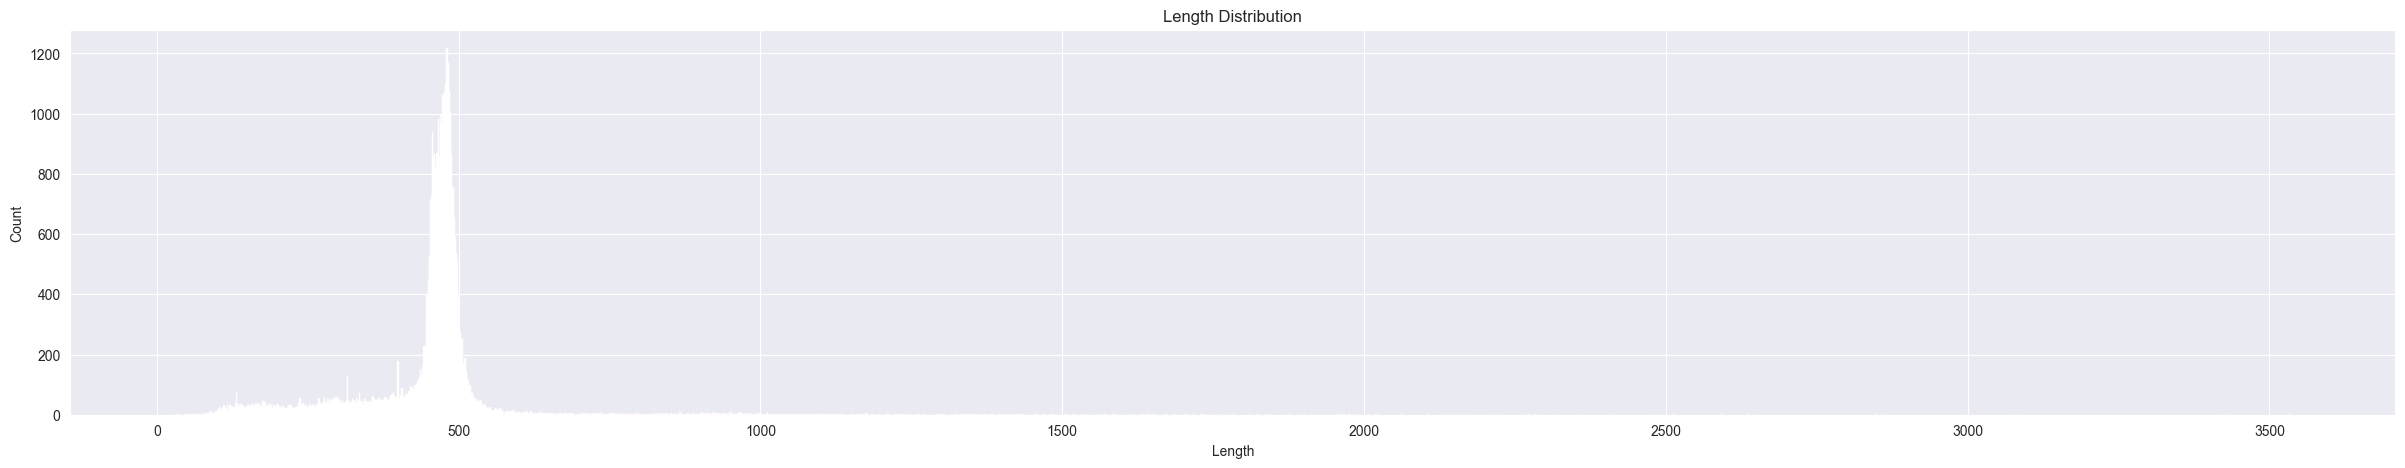

In [199]:
plt.figure(figsize=(30, 5))
plt.bar(length_d.keys(), length_d.values(), color='red')
plt.xlabel('Length')
plt.ylabel('Count')
plt.title('Length Distribution')
plt.show()

In [209]:
coun = [k for k, v in length_d.items() for _ in range(v)]
median_value = np.median(coun)
mean_vlaue = np.mean(coun)
max_value = np.max(coun)
min_value = np.min(coun)
print("Max:",max_value)
print("Min:",min_value)
print("Mean:",mean_vlaue)
print("Median",median_value)

Max: 3533
Min: 32
Mean: 452.79140124967694
Median 470.0


In [174]:
plt.figure(figsize=(12, 6))
organism1 = organism.head(10)
plt.bar(organism1.keys(), organism1.values(), color='#FFA500')
plt.xlabel('Organism')
plt.ylabel('Count')
plt.title('Organism Distribution')
plt.xticks(rotation=90)
plt.setp(plt.gca().get_xticklabels(), fontsize=6)  # 使用setp设置x轴标签字体大小
plt.tight_layout()
plt.show()

AttributeError: 'dict' object has no attribute 'head'

<Figure size 1200x600 with 0 Axes>

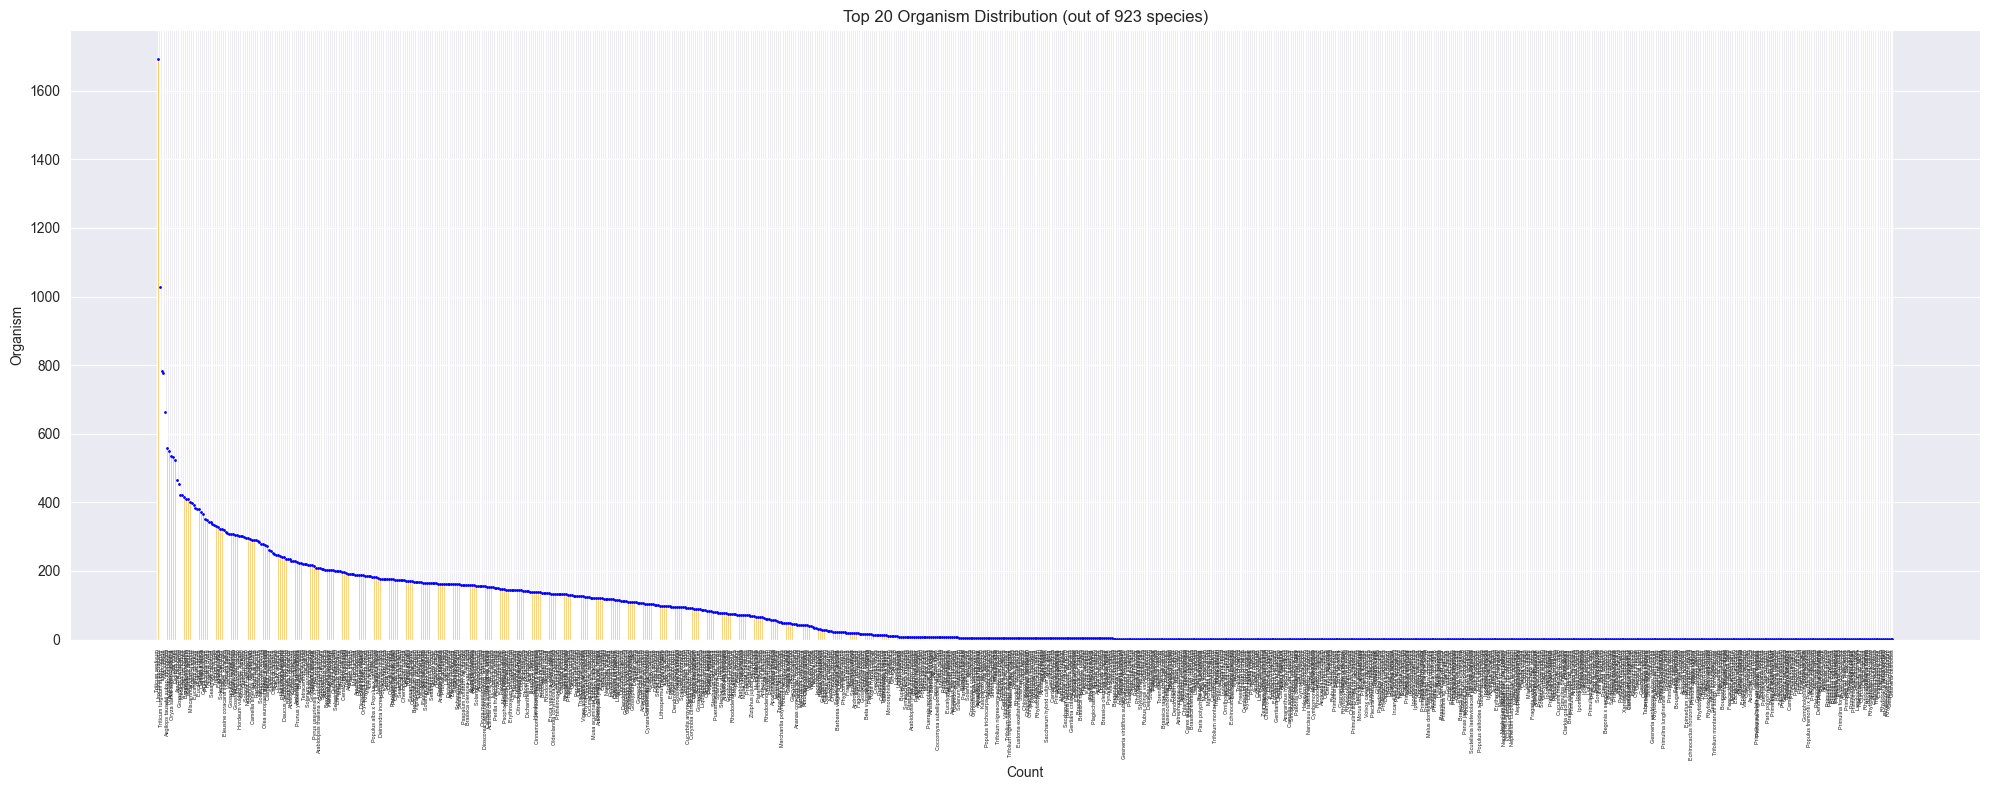

In [187]:
top_n = 20
df = pd.DataFrame(list(organism.items()), columns=['Organism', 'Count'])
df_sorted = df.sort_values('Count', ascending=False).head(1000)
plt.figure(figsize=(20, 8))  # 稍微调高一点高度
plt.bar(df_sorted['Organism'], df_sorted['Count'], color='#FFA500')
plt.plot(df_sorted['Organism'],df_sorted['Count'], 'o', markersize=1, color='blue')
plt.xlabel('Count')
plt.xticks(rotation=90)
plt.ylabel('Organism')
plt.title(f'Top {top_n} Organism Distribution (out of {len(organism)} species)')
plt.setp(plt.gca().get_xticklabels(), fontsize=4)  # 使用setp设置x轴标签字体大小
plt.tight_layout()
plt.show()

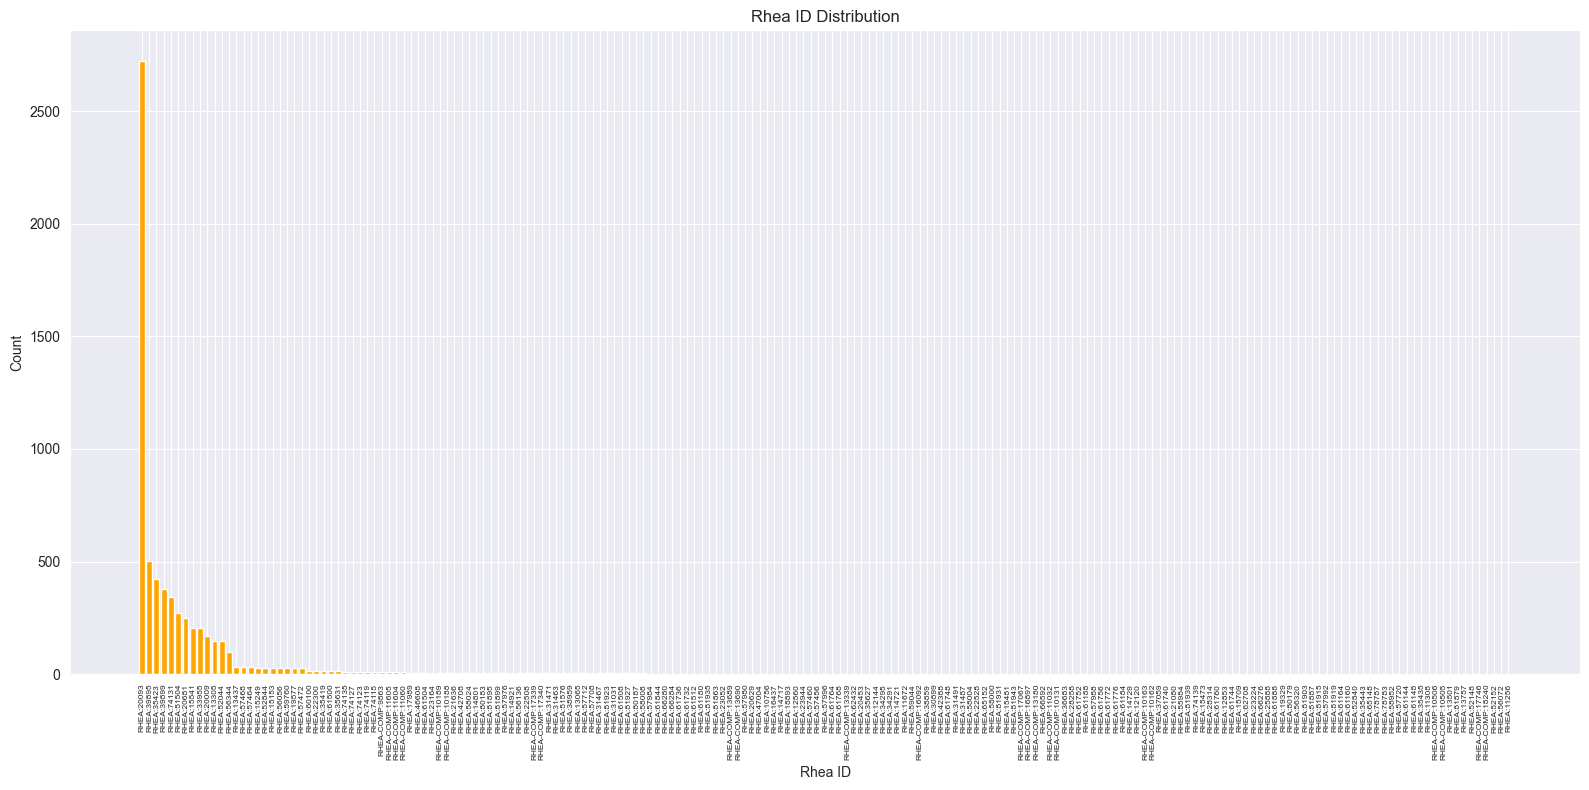

In [190]:
df1 = pd.DataFrame(list(rhea_ids.items()), columns=['rhea_ids', 'Count'])
df_sorted1 = df1.sort_values('Count', ascending=False).head(1000)
plt.figure(figsize=(16, 8))
plt.bar(df_sorted1['rhea_ids'], df_sorted1['Count'], color='#FFA500')
plt.xlabel('Rhea ID')
plt.ylabel('Count')
plt.title('Rhea ID Distribution')
plt.xticks(rotation=90)
plt.setp(plt.gca().get_xticklabels(), fontsize=6)
plt.tight_layout()
plt.show()

In [1]:
# 对数据进行筛选

In [240]:
# 这里对长度进行筛选，仅保留长度在350~600AA的数据
for sub_data in copy_data:
    if sub_data['length'] < 350 or sub_data['length'] > 600:
        copy_data.remove(sub_data)

In [241]:
organism = {}
length_d = {}
rhea_ids = {}
for d in copy_data:
    if d['length'] in length_d.keys():
        length_d[d['length']] += 1
    else:
        length_d[d['length']] = 1
    if d['organism'] in organism.keys():
        organism[d['organism']] += 1
    else:
        organism[d['organism']] = 1
    if d['reactions']:
        for r in d['reactions']:
            if r['rhea_ids']:
                for rhea_id in r['rhea_ids']:
                    if rhea_id in rhea_ids.keys():
                        rhea_ids[rhea_id] += 1
                    else:
                        rhea_ids[rhea_id] = 1
    else:
        continue

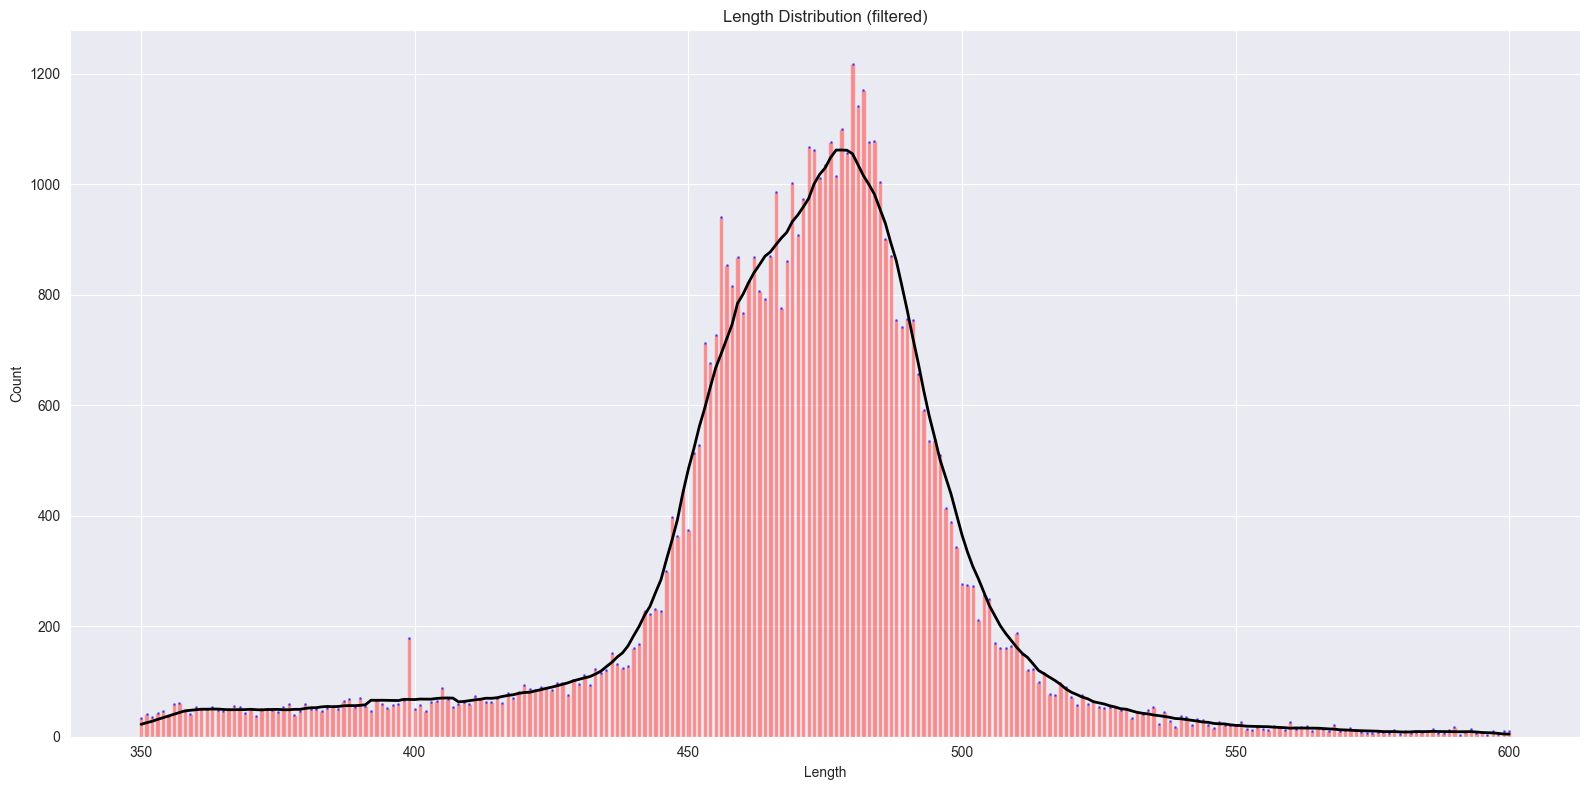

In [248]:
items = sorted(length_d.items(), key=lambda x: x[0])
x = np.array([k for k, v in items])
y = np.array([v for k, v in items], dtype=float)
# 2. 对 y 做平滑（简单移动平均）
window = 16  # 窗口大小，可以调大/调小看效果（必须是正整数）
kernel = np.ones(window) / window
y_smooth = np.convolve(y, kernel, mode='same')
# 3. 画图
plt.figure(figsize=(16, 8))
# 柱状 + 散点（你原来的）
plt.bar(x, y, color='red', alpha=0.4)
plt.plot(x, y, 'o', markersize=1, color='blue', alpha=0.5)
# 平滑曲线（整体趋势）
plt.plot(x, y_smooth, linewidth=2, color='black')
plt.xlabel('Length')
plt.ylabel('Count')
plt.title('Length Distribution (filtered)')
plt.tight_layout()
plt.show()

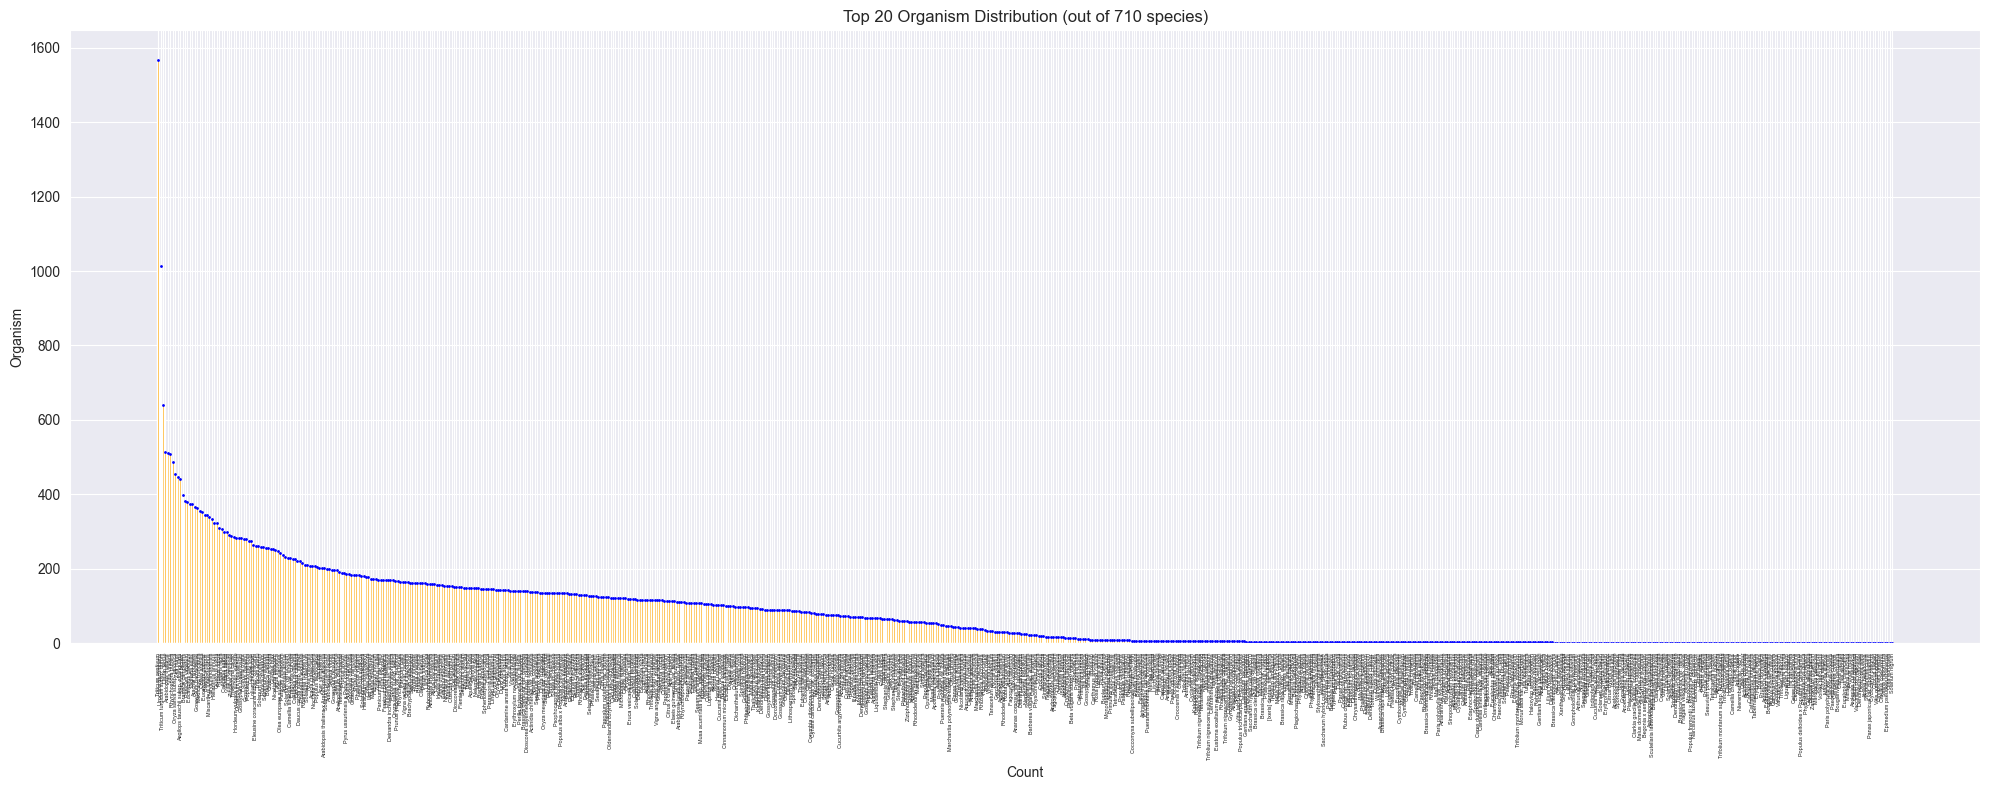

In [249]:
top_n = 20
df = pd.DataFrame(list(organism.items()), columns=['Organism', 'Count'])
df_sorted = df.sort_values('Count', ascending=False).head(1000)
plt.figure(figsize=(20, 8))  # 稍微调高一点高度
plt.bar(df_sorted['Organism'], df_sorted['Count'], color='#FFA500')
plt.plot(df_sorted['Organism'],df_sorted['Count'], 'o', markersize=1, color='blue')
plt.xlabel('Count')
plt.xticks(rotation=90)
plt.ylabel('Organism')
plt.title(f'Top {top_n} Organism Distribution (out of {len(organism)} species)')
plt.setp(plt.gca().get_xticklabels(), fontsize=4)  # 使用setp设置x轴标签字体大小
plt.tight_layout()
plt.show()

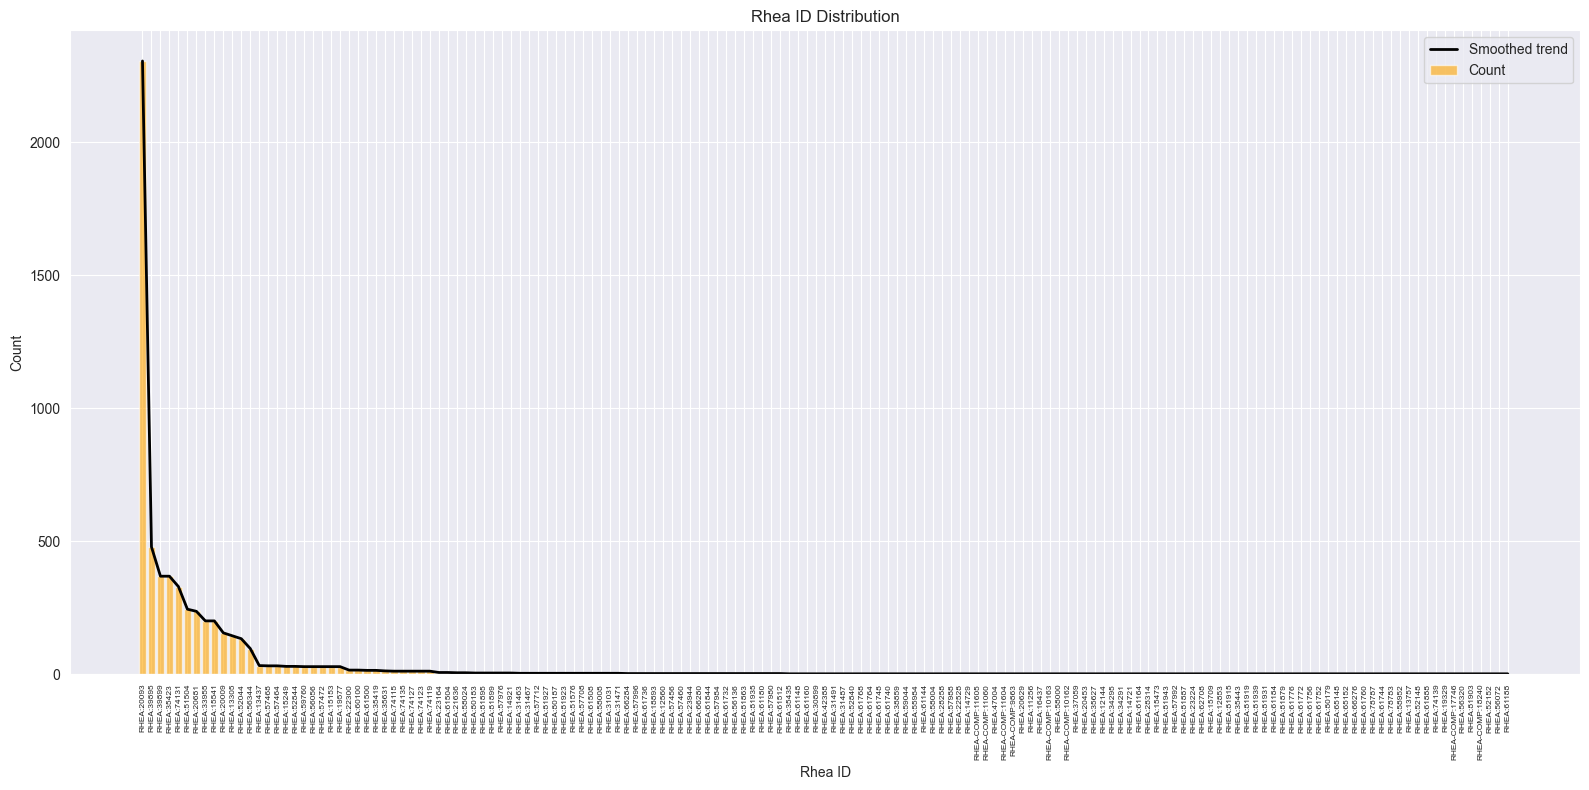

In [256]:
df1 = pd.DataFrame(list(rhea_ids.items()), columns=['rhea_ids', 'Count'])
df_sorted1 = df1.sort_values('Count', ascending=False).head(1000)
# 给每个 Rhea ID 一个 x 轴数值位置
x_idx = np.arange(len(df_sorted1))
y = df_sorted1['Count'].values.astype(float)
# ---- 平滑曲线：简单移动平均 ----
window = 1  # 窗口大小，可以调大/调小（必须是整数，越大越平滑）
window = min(window, len(y))  # 防止窗口比数据还长
kernel = np.ones(window) / window
y_smooth = np.convolve(y, kernel, mode='same')
plt.figure(figsize=(16, 8))
# 柱状图（分布）
plt.bar(x_idx, y, color='#FFA500', alpha=0.6, label='Count')
# 平滑曲线（趋势）
plt.plot(x_idx, y_smooth, linewidth=2, color='black', label='Smoothed trend')
plt.xlabel('Rhea ID')
plt.ylabel('Count')
plt.title('Rhea ID Distribution')
# x 轴刻度用 Rhea ID 字符串
plt.xticks(x_idx, df_sorted1['rhea_ids'], rotation=90)
plt.setp(plt.gca().get_xticklabels(), fontsize=6)
plt.legend()
plt.tight_layout()
plt.show()

In [259]:
df_sorted1

,rhea_ids,Count
47,RHEA:20093,2305
86,RHEA:39895,478
96,RHEA:39899,368
24,RHEA:35423,368
45,RHEA:74131,329
...,...,...
97,RHEA:81903,1
31,RHEA-COMP:18240,1
32,RHEA:52152,1
35,RHEA:56072,1


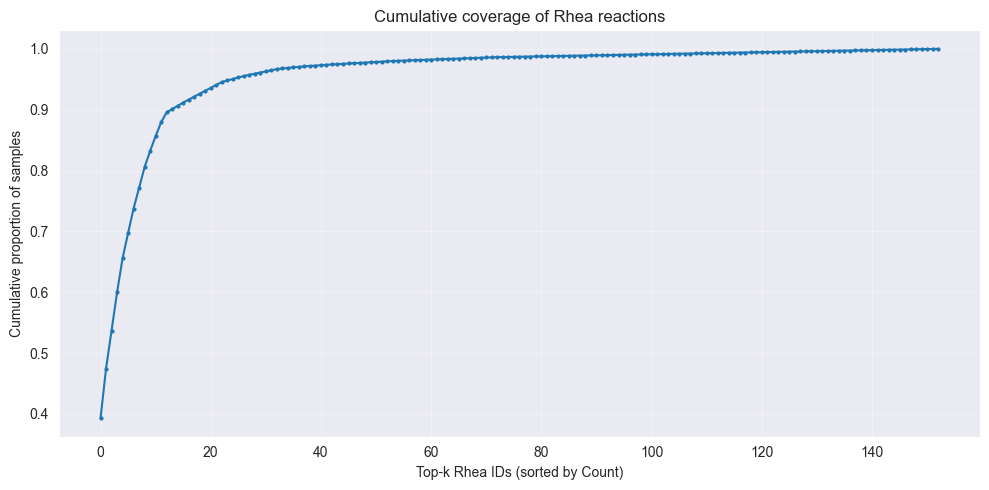

In [260]:
y = df_sorted1['Count'].values.astype(float)
cum = np.cumsum(y)
cum_ratio = cum / cum[-1]  # 转成 0~1
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(y)), cum_ratio, marker='o', markersize=2)
plt.xlabel('Top-k Rhea IDs (sorted by Count)')
plt.ylabel('Cumulative proportion of samples')
plt.title('Cumulative coverage of Rhea reactions')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [261]:
len(copy_data)

55351

In [263]:
if copy_data:
    # 1. 保存为 JSON (保留所有嵌套细节，训练模型主要用这个)
    json_filename = os.path.join(save_path,'ugt_full_dataset_QC.json')
    with open(json_filename, 'w', encoding='utf-8') as f:
        json.dump(copy_data, f, indent=2, ensure_ascii=False)
    
    # 2. 保存简略版 CSV (用于人工查看统计)
    # 扁平化处理一下以便存入 CSV
    csv_data = []
    for d in copy_data:
        simple_row = {
            'id': d['uniprot_id'],
            'quality_level': d['data_quality_level'],
            'organism': d['organism'],
            'len': d['length'],
            'has_pdb': len(d['structures']['pdb']) > 0,
            'km_count': len(d['kinetics']['km']),
            'rhea_count': len(d['reactions'])
        }
        csv_data.append(simple_row)
        
    df = pd.DataFrame(csv_data)
    df.to_csv(os.path.join(save_path,'ugt_summary_QC.csv'), index=False)
    
    print(f"\n🎉 抓取完成！耗时 {time.time() - start_time:.2f} 秒")
    print(f"📂 完整数据已保存至: {json_filename}")
    print(f"📊 统计摘要已保存至: 'ugt_summary.csv'")
    print("-" * 30)
    print(f"数据质量统计:")
    print(df['quality_level'].value_counts().sort_index().rename({
        1: 'Level 1 (Gold: Reviewed/Kinetics)',
        2: 'Level 2 (Silver: Specific Reaction)',
        3: 'Level 3 (Bronze: Sequence Only)'
    }))
else:
    print("未获取到数据。")


🎉 抓取完成！耗时 17483.58 秒
📂 完整数据已保存至: E:\pUGTdb\20251128_collection\download_PF00201_taxonomy33090\download_data\ugt_full_dataset_QC.json
📊 统计摘要已保存至: 'ugt_summary.csv'
------------------------------
数据质量统计:
Level 1 (Gold: Reviewed/Kinetics)         78
Level 2 (Silver: Specific Reaction)     4931
Level 3 (Bronze: Sequence Only)        50342
Name: quality_level, dtype: int64


In [279]:
Step_df = pd.DataFrame(copy_data)

In [278]:
Step_df.to_csv(r'E:\pUGTdb\20251128_collection\download_PF00201_taxonomy33090\download_data\PF00201_taxonomy_Uniprot.csv')

In [335]:
Step1_df = Step_df[Step_df['data_quality_level']==3] 

In [295]:
Step1_df.to_csv(r'E:\pUGTdb\20251128_collection\download_PF00201_taxonomy33090\download_data\PF00201_taxonomy_Uniprot_Level3(pretrain).csv')

In [296]:
Step2_df = Step_df[Step_df['data_quality_level'] == 2] 

In [346]:
all_reaction_rhea_ids = []
specificity_count = 0
mask_to_delete = pd.Series([False] * len(Step2_df), index=Step2_df.index)
for index, row in Step2_df.iterrows():
    reactions = row['reactions']
    for reaction in reactions:
        if len(reaction['rhea_ids']) == 0:
            specificity_count += 1
            mask_to_delete.at[index] = True
            continue
        rhea_ids = reaction['rhea_ids'][0]
        if rhea_ids not in all_reaction_rhea_ids:
            all_reaction_rhea_ids.append(rhea_ids)
        # if reaction['specificity'] != 'Specific':
        #     specificity_count += 1
Step2_cleaned = Step2_df[~mask_to_delete] 

In [347]:
len(all_reaction_rhea_ids)

96

In [353]:
Step2_df_norm = Step2_cleaned.explode('reactions').reset_index(drop=True)
reactions_df = pd.json_normalize(Step2_df_norm['reactions']).add_prefix('reaction_')
final_df = pd.concat([Step2_df_norm.drop(columns='reactions'), reactions_df], axis=1)

In [546]:
final_df

,uniprot_id,entry_name,is_reviewed,organism,organism_id,length,sequence,gene_name,data_quality_level,kinetics,ph_temp,structures,sites,references,reaction_text,reaction_rhea_ids,reaction_specificity
0,A0A0K0PVW1,UGT10_PANGI,Swiss-Prot,Panax ginseng,4054,472,MKSELIFLPVPAFGHLVGMVEMAKLFISRHENLSVTVLISKFFIDT...,UGT100,2,"{'km': [], 'kcat': [], 'vmax': []}","{'ph': None, 'temp': None}","{'pdb': [], 'alphafold': ['A0A0K0PVW1']}","{'active_sites': [{'pos': 15, 'desc': 'Proton ...",[],(20S)-protopanaxadiol + UDP-alpha-D-glucose = ...,[RHEA:57976],Specific
1,A0A0K0PVW1,UGT10_PANGI,Swiss-Prot,Panax ginseng,4054,472,MKSELIFLPVPAFGHLVGMVEMAKLFISRHENLSVTVLISKFFIDT...,UGT100,2,"{'km': [], 'kcat': [], 'vmax': []}","{'ph': None, 'temp': None}","{'pdb': [], 'alphafold': ['A0A0K0PVW1']}","{'active_sites': [{'pos': 15, 'desc': 'Proton ...",[],(20S)-protopanaxatriol + UDP-alpha-D-glucose =...,[RHEA:58952],Specific
2,A0A0K0PVW1,UGT10_PANGI,Swiss-Prot,Panax ginseng,4054,472,MKSELIFLPVPAFGHLVGMVEMAKLFISRHENLSVTVLISKFFIDT...,UGT100,2,"{'km': [], 'kcat': [], 'vmax': []}","{'ph': None, 'temp': None}","{'pdb': [], 'alphafold': ['A0A0K0PVW1']}","{'active_sites': [{'pos': 15, 'desc': 'Proton ...",[],(20S)-ginsenoside F1 + UDP-alpha-D-glucose = (...,[RHEA:58008],Specific
3,P0DO58,F3GT1_RHODL,Swiss-Prot,Rhododendron delavayi,321363,464,MTKNISRDRHVAVLPFPFSSHAGRLLTLVRRLAAAAPNVTFSFYST...,3GT1,2,"{'km': [], 'kcat': [], 'vmax': []}","{'ph': 'Optimum pH is 8.', 'temp': 'Optimum te...","{'pdb': [], 'alphafold': []}","{'active_sites': [{'pos': 21, 'desc': 'Proton ...",[],cyanidin + UDP-alpha-D-galactose = cyanidin 3-...,[RHEA:35631],Specific
4,P0DO58,F3GT1_RHODL,Swiss-Prot,Rhododendron delavayi,321363,464,MTKNISRDRHVAVLPFPFSSHAGRLLTLVRRLAAAAPNVTFSFYST...,3GT1,2,"{'km': [], 'kcat': [], 'vmax': []}","{'ph': 'Optimum pH is 8.', 'temp': 'Optimum te...","{'pdb': [], 'alphafold': []}","{'active_sites': [{'pos': 21, 'desc': 'Proton ...",[],cyanidin + UDP-alpha-D-glucose = cyanidin 3-O-...,[RHEA:60100],Specific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5601,S8DSE1,S8DSE1_9LAMI,TrEMBL,Genlisea aurea,192259,479,AVAGGERKPHALCIPFPAQGHITPMLNLSKLLHEKGFHVTFVNTHY...,,2,"{'km': [], 'kcat': [], 'vmax': []}","{'ph': None, 'temp': None}","{'pdb': [], 'alphafold': ['S8DSE1']}","{'active_sites': [], 'binding_sites': []}",[],7-deoxyloganetin + UDP-alpha-D-glucose = 7-deo...,[RHEA:39899],Specific
5602,W8PUL7,W8PUL7_ARATH,TrEMBL,Arabidopsis thaliana,3702,475,MEMESSLPHVMLVSFPGQGHISPLLRLGKIIASKGLIVTFVTTEEP...,,2,"{'km': [], 'kcat': [], 'vmax': []}","{'ph': None, 'temp': None}","{'pdb': [], 'alphafold': ['W8PUL7']}","{'active_sites': [], 'binding_sites': []}",[],(E)-sinapate + UDP-alpha-D-glucose = 1-O-(tran...,[RHEA:13305],Specific
5603,W8Q6K4,W8Q6K4_ARATH,TrEMBL,Arabidopsis thaliana,3702,490,MGSISEMVFETCPSPNPIHVMLVSFQGQGHVNPLLRLGKLIASKGL...,,2,"{'km': [], 'kcat': [], 'vmax': []}","{'ph': None, 'temp': None}","{'pdb': [], 'alphafold': ['W8Q6K4']}","{'active_sites': [], 'binding_sites': []}",[],(E)-sinapate + UDP-alpha-D-glucose = 1-O-(tran...,[RHEA:13305],Specific
5604,W8QNG3,W8QNG3_ARATH,TrEMBL,Arabidopsis thaliana,3702,479,MDPSRHTHVMLVSFPGQGHVNPLLRLGKLIASKGLLVTFVTTEKPW...,,2,"{'km': [], 'kcat': [], 'vmax': []}","{'ph': None, 'temp': None}","{'pdb': [], 'alphafold': ['W8QNG3']}","{'active_sites': [], 'binding_sites': []}",[],(E)-sinapate + UDP-alpha-D-glucose = 1-O-(tran...,[RHEA:13305],Specific


In [374]:
Rhea_EC2_path = r'E:\pUGTdb\20251128_collection\download_PF00201_taxonomy33090\rhea-reaction-smiles.tsv'
rhea_ec_df = pd.read_csv(Rhea_EC2_path, sep='\t', header=None, names=['rhea_id', 'reaction_SMILES'])

In [538]:
BASE_URL = "https://www.rhea-db.org/rhea/{}"
PUBCHEM_API_URL = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/substance/sourceid/chebi/{}/property/IsomericSMILES/JSON"

def scrape_rhea_page(rid):
    """爬取单个 Rhea 网页并解析"""
    url = BASE_URL.format(rid)
    try:
        resp = requests.get(url, timeout=30)
        if resp.status_code != 200:
            print(f"Failed to load page: {url}")
            return None
        soup = BeautifulSoup(resp.text, 'html.parser')
        rhea_input = soup.find('input', id='rheaId')
        rhea_id = f"RHEA:{rhea_input['value']}" if rhea_input else "Unknown"
        ec_tag = soup.find('a', attrs={'data-molid': re.compile(r'^ec:')})
        ec_number = ec_tag.text.strip().replace("EC ", "") if ec_tag else "None"
        eq_tag = soup.find('textarea', id='equationtext')
        equation = eq_tag.text.strip() if eq_tag else ""
        mol_map = {}
        participant_list = soup.find('ul', class_='participants')
        if participant_list:
            items = participant_list.find_all('li', class_='participant')
            for item in items:
                name_tag = item.find('a', class_='molName')
                name = name_tag.text.strip() if name_tag else ""
                # 提取 SMILES
                smiles = "Unknown"
                spans = item.find_all('span', class_='cell')
                for i, span in enumerate(spans):
                    if 'SMILES' in span.text:
                        if i + 1 < len(spans):
                            smiles = spans[i+1].text.strip()
                        break
                
                if name and smiles != "Unknown":
                    mol_map[name] = smiles
        return {
            'rhea_id': rhea_id,
            'ec_number': ec_number,
            'equation': equation,
            'participants': [
                {
                    'name': name,
                    'smiles': smiles
                }
                for name, smiles in mol_map.items()
            ]
        }
    except:
        print(f"Failed to scrape page: {url}")
        
results = {}
for rid in tqdm(all_reaction_rhea_ids):
    rid_n =rid[5:]
    data = scrape_rhea_page(rid_n)
    if data:
        results[rid] =  data

df_REACTIONS = pd.DataFrame(results)
# df.to_csv('rhea_web_scraped.csv', index=False, encoding='utf-8-sig')
print("\n爬取完成！结果已保存至 rhea_web_scraped.csv")


100%|██████████| 96/96 [01:36<00:00,  1.00s/it]


爬取完成！结果已保存至 rhea_web_scraped.csv


In [583]:
# 这里去除数据集中不是糖基转移酶的数据，也很困惑为什么会收上来这种数据
for k,v in results.items():
    if v['ec_number'][0] != '2':
        print(k, v['ec_number'])
del results['RHEA:14729']
del results['RHEA:20629']
del results['RHEA:47004']
del results['RHEA:11256']

RHEA:61512 None
RHEA:74119 None
RHEA:74123 None
RHEA:74127 None
RHEA:74131 None
RHEA:74135 None
RHEA:74115 None
RHEA:74139 None
RHEA:80179 None
RHEA:80183 None
RHEA:81887 None
RHEA:81895 None
RHEA:81899 None
RHEA:81915 None
RHEA:81919 None
RHEA:81923 None
RHEA:81863 None
RHEA:81939 None
RHEA:61180 None
RHEA:57472 None
RHEA:57464 None
RHEA:57468 None
RHEA:80187 None
RHEA:81927 None
RHEA:81935 None
RHEA:81903 None
RHEA:56320 None
RHEA:61888 None
RHEA:66276 None
RHEA:61844 None
RHEA:66280 None
RHEA:66284 None
RHEA:61164 None
RHEA:61160 None
RHEA:61148 None
RHEA:61144 None
RHEA:61740 None
RHEA:61748 None
RHEA:61764 None
RHEA:61768 None


In [585]:
with open(r'E:\pUGTdb\20251128_collection\download_PF00201_taxonomy33090\rhea_reactions.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

In [594]:
final_df['acceptor'] = None
final_df['donor'] = None
final_df['get_loop'] = None
final_df['lost_loop'] = None
final_df['H'] = None
final_df['H2'] = None

In [589]:
results['RHEA:81927']['participants']

[{'name': 'mogroside III',
  'smiles': 'O[C@H]1[C@@]2([C@]([C@]3([C@@]([C@](CC3)([C@@H](CC[C@@H](O[C@@H]4O[C@@H]([C@@H](O)[C@H](O)[C@H]4O[C@@H]5O[C@@H]([C@@H](O)[C@H](O)[C@H]5O)CO)CO)C(O)(C)C)C)[H])(C1)C)C)(CC=C6[C@]2(CC[C@H](O[C@@H]7O[C@@H]([C@@H](O)[C@H](O)[C@H]7O)CO)C6(C)C)[H])[H])C'},
 {'name': 'UDP-α-D-glucose',
  'smiles': 'OC[C@H]1O[C@H](OP([O-])(=O)OP([O-])(=O)OC[C@H]2O[C@H]([C@H](O)[C@@H]2O)n2ccc(=O)[nH]c2=O)[C@H](O)[C@@H](O)[C@@H]1O'},
 {'name': 'siamenoside I',
  'smiles': 'O[C@H]1[C@@]2([C@]([C@]3([C@@]([C@](CC3)([C@@H](CC[C@@H](O[C@@H]4O[C@@H]([C@@H](O)[C@H](O)[C@H]4O[C@@H]5O[C@@H]([C@@H](O)[C@H](O)[C@H]5O)CO)CO[C@@H]6O[C@@H]([C@@H](O)[C@H](O)[C@H]6O)CO)C(O)(C)C)C)[H])(C1)C)C)(CC=C7[C@]2(CC[C@H](O[C@@H]8O[C@@H]([C@@H](O)[C@H](O)[C@H]8O)CO)C7(C)C)[H])[H])C'},
 {'name': 'UDP',
  'smiles': 'O[C@@H]1[C@@H](COP([O-])(=O)OP([O-])([O-])=O)O[C@H]([C@@H]1O)n1ccc(=O)[nH]c1=O'},
 {'name': 'H+', 'smiles': '[H+]'}]

In [596]:
for index, row in final_df.iterrows():
    rhea = row['reaction_rhea_ids'][0]
    try:
        rhea_data = results[rhea]['participants']
    except:
        continue
    if 'UDP' in rhea_data[0]['name']:
        acceptor = rhea_data[1]['smiles']
        donor = rhea_data[0]['smiles']
    elif 'UDP' in rhea_data[1]['name']:
        acceptor = rhea_data[0]['smiles']
        donor = rhea_data[1]['smiles']
    
    if rhea_data[2]['name'] == 'H+' and len(rhea_data) == 5:
        get_loop = rhea_data[3]['smiles']
        lost_loop = rhea_data[4]['smiles']
        H = rhea_data[2]['smiles']
    elif len(rhea_data) == 4:
        get_loop = rhea_data[2]['smiles']
        lost_loop = rhea_data[3]['smiles']
    
    if len(rhea_data) not in [4, 5]:
        print(f"Rhea {rhea} has {len(rhea_data)} participants.")
        continue

    final_df.at[index, 'acceptor'] = acceptor
    final_df.at[index, 'donor'] = donor
    final_df.at[index, 'get_loop'] = get_loop
    final_df.at[index, 'lost_loop'] = lost_loop
    if len(rhea_data) == 5:
        final_df.at[index, 'H'] = H

Rhea RHEA:37059 has 7 participants.


In [597]:
final_df

,uniprot_id,entry_name,is_reviewed,organism,organism_id,length,sequence,gene_name,data_quality_level,kinetics,...,reaction_text,reaction_rhea_ids,reaction_specificity,acceptor,donor,get_loop,lost_loop,H,H1,H2
0,A0A0K0PVW1,UGT10_PANGI,Swiss-Prot,Panax ginseng,4054,472,MKSELIFLPVPAFGHLVGMVEMAKLFISRHENLSVTVLISKFFIDT...,UGT100,2,"{'km': [], 'kcat': [], 'vmax': []}",...,(20S)-protopanaxadiol + UDP-alpha-D-glucose = ...,[RHEA:57976],Specific,CC(C)=CCC[C@](C)(O)[C@H]1CC[C@]2(C)[C@@H]1[C@H...,OC[C@H]1O[C@H](OP([O-])(=O)OP([O-])(=O)OC[C@H]...,COc1cc(cc(OC)c1O)\C=C\C(=O)O[C@@H]1O[C@H](CO)[...,O[C@@H]1[C@@H](COP([O-])(=O)OP([O-])([O-])=O)O...,[H+],None,None
1,A0A0K0PVW1,UGT10_PANGI,Swiss-Prot,Panax ginseng,4054,472,MKSELIFLPVPAFGHLVGMVEMAKLFISRHENLSVTVLISKFFIDT...,UGT100,2,"{'km': [], 'kcat': [], 'vmax': []}",...,(20S)-protopanaxatriol + UDP-alpha-D-glucose =...,[RHEA:58952],Specific,CC(C)=CCC[C@](C)(O)[C@H]1CC[C@]2(C)[C@@H]1[C@H...,OC[C@H]1O[C@H](OP([O-])(=O)OP([O-])(=O)OC[C@H]...,COc1cc(cc(OC)c1O)\C=C\C(=O)O[C@@H]1O[C@H](CO)[...,O[C@@H]1[C@@H](COP([O-])(=O)OP([O-])([O-])=O)O...,[H+],None,None
2,A0A0K0PVW1,UGT10_PANGI,Swiss-Prot,Panax ginseng,4054,472,MKSELIFLPVPAFGHLVGMVEMAKLFISRHENLSVTVLISKFFIDT...,UGT100,2,"{'km': [], 'kcat': [], 'vmax': []}",...,(20S)-ginsenoside F1 + UDP-alpha-D-glucose = (...,[RHEA:58008],Specific,CC(C)=CCC[C@](C)(O[C@@H]1O[C@H](CO)[C@@H](O)[C...,OC[C@H]1O[C@H](OP([O-])(=O)OP([O-])(=O)OC[C@H]...,COc1cc(cc(OC)c1O)\C=C\C(=O)O[C@@H]1O[C@H](CO)[...,O[C@@H]1[C@@H](COP([O-])(=O)OP([O-])([O-])=O)O...,[H+],None,None
3,P0DO58,F3GT1_RHODL,Swiss-Prot,Rhododendron delavayi,321363,464,MTKNISRDRHVAVLPFPFSSHAGRLLTLVRRLAAAAPNVTFSFYST...,3GT1,2,"{'km': [], 'kcat': [], 'vmax': []}",...,cyanidin + UDP-alpha-D-galactose = cyanidin 3-...,[RHEA:35631],Specific,Oc1cc([O-])c2cc([O-])c([o+]c2c1)-c1ccc(O)c(O)c1,OC[C@H]1O[C@H](OP([O-])(=O)OP([O-])(=O)OC[C@H]...,COc1cc(cc(OC)c1O)\C=C\C(=O)O[C@@H]1O[C@H](CO)[...,O[C@@H]1[C@@H](COP([O-])(=O)OP([O-])([O-])=O)O...,[H+],None,None
4,P0DO58,F3GT1_RHODL,Swiss-Prot,Rhododendron delavayi,321363,464,MTKNISRDRHVAVLPFPFSSHAGRLLTLVRRLAAAAPNVTFSFYST...,3GT1,2,"{'km': [], 'kcat': [], 'vmax': []}",...,cyanidin + UDP-alpha-D-glucose = cyanidin 3-O-...,[RHEA:60100],Specific,Oc1cc([O-])c2cc([O-])c([o+]c2c1)-c1ccc(O)c(O)c1,OC[C@H]1O[C@H](OP([O-])(=O)OP([O-])(=O)OC[C@H]...,COc1cc(cc(OC)c1O)\C=C\C(=O)O[C@@H]1O[C@H](CO)[...,O[C@@H]1[C@@H](COP([O-])(=O)OP([O-])([O-])=O)O...,[H+],None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5601,S8DSE1,S8DSE1_9LAMI,TrEMBL,Genlisea aurea,192259,479,AVAGGERKPHALCIPFPAQGHITPMLNLSKLLHEKGFHVTFVNTHY...,,2,"{'km': [], 'kcat': [], 'vmax': []}",...,7-deoxyloganetin + UDP-alpha-D-glucose = 7-deo...,[RHEA:39899],Specific,COC(=O)C1=CO[C@@H](O)[C@@H]2[C@@H](C)CC[C@H]12,OC[C@H]1O[C@H](OP([O-])(=O)OP([O-])(=O)OC[C@H]...,COc1cc(cc(OC)c1O)\C=C\C(=O)O[C@@H]1O[C@H](CO)[...,O[C@@H]1[C@@H](COP([O-])(=O)OP([O-])([O-])=O)O...,[H+],None,None
5602,W8PUL7,W8PUL7_ARATH,TrEMBL,Arabidopsis thaliana,3702,475,MEMESSLPHVMLVSFPGQGHISPLLRLGKIIASKGLIVTFVTTEEP...,,2,"{'km': [], 'kcat': [], 'vmax': []}",...,(E)-sinapate + UDP-alpha-D-glucose = 1-O-(tran...,[RHEA:13305],Specific,COc1cc(cc(OC)c1O)\C=C\C([O-])=O,OC[C@H]1O[C@H](OP([O-])(=O)OP([O-])(=O)OC[C@H]...,COc1cc(cc(OC)c1O)\C=C\C(=O)O[C@@H]1O[C@H](CO)[...,O[C@@H]1[C@@H](COP([O-])(=O)OP([O-])([O-])=O)O...,None,None,None
5603,W8Q6K4,W8Q6K4_ARATH,TrEMBL,Arabidopsis thaliana,3702,490,MGSISEMVFETCPSPNPIHVMLVSFQGQGHVNPLLRLGKLIASKGL...,,2,"{'km': [], 'kcat': [], 'vmax': []}",...,(E)-sinapate + UDP-alpha-D-glucose = 1-O-(tran...,[RHEA:13305],Specific,COc1cc(cc(OC)c1O)\C=C\C([O-])=O,OC[C@H]1O[C@H](OP([O-])(=O)OP([O-])(=O)OC[C@H]...,COc1cc(cc(OC)c1O)\C=C\C(=O)O[C@@H]1O[C@H](CO)[...,O[C@@H]1[C@@H](COP([O-])(=O)OP([O-])([O-])=O)O...,None,None,None
5604,W8QNG3,W8QNG3_ARATH,TrEMBL,Arabidopsis thaliana,3702,479,MDPSRHTHVMLVSFPGQGHVNPLLRLGKLIASKGLLVTFVTTEKPW...,,2,"{'km': [], 'kcat': [], 'vmax': []}",...,(E)-sinapate + UDP-alpha-D-

In [599]:
final_df.to_csv(r'E:\pUGTdb\20251128_collection\download_PF00201_taxonomy33090\download_data\PF00201_taxonomy_Uniprot_Level2(condition_generation).csv')

In [9]:
aaa =pd.read_csv(r"E:\pUGTdb\20251128_collection\download_PF00201_taxonomy33090\download_data\PF00201_taxonomy_Uniprot_Level2(condition_generation).csv")
aaa['reaction_rhea_ids'].tolist()

["['RHEA:57976']",
 "['RHEA:58952']",
 "['RHEA:58008']",
 "['RHEA:35631']",
 "['RHEA:60100']",
 "['RHEA:61500']",
 "['RHEA:61512']",
 "['RHEA:74119']",
 "['RHEA:74123']",
 "['RHEA:74127']",
 "['RHEA:74131']",
 "['RHEA:74135']",
 "['RHEA:20093']",
 "['RHEA:74115']",
 "['RHEA:61508']",
 "['RHEA:61504']",
 "['RHEA:74139']",
 "['RHEA:80179']",
 "['RHEA:80183']",
 "['RHEA:81887']",
 "['RHEA:81895']",
 "['RHEA:81899']",
 "['RHEA:81915']",
 "['RHEA:81919']",
 "['RHEA:81923']",
 "['RHEA:81863']",
 "['RHEA:81939']",
 "['RHEA:23164']",
 "['RHEA:22300']",
 "['RHEA:61180']",
 "['RHEA:35443']",
 "['RHEA:23224']",
 "['RHEA:57472']",
 "['RHEA:57464']",
 "['RHEA:13437']",
 "['RHEA:57468']",
 "['RHEA:15249']",
 "['RHEA:52844']",
 "['RHEA:15153']",
 "['RHEA:59760']",
 "['RHEA:56056']",
 "['RHEA:19577']",
 "['RHEA:80187']",
 "['RHEA:81927']",
 "['RHEA:81935']",
 "['RHEA:52044']",
 "['RHEA:81903']",
 "['RHEA:56320']",
 "['RHEA:35419']",
 "['RHEA:19329']",
 "['RHEA:61888']",
 "['RHEA:66276']",
 "['RHEA:618

0       ['RHEA:57976']
1       ['RHEA:58952']
2       ['RHEA:58008']
3       ['RHEA:35631']
4       ['RHEA:60100']
             ...      
5596    ['RHEA:39899']
5597    ['RHEA:13305']
5598    ['RHEA:13305']
5599    ['RHEA:13305']
5600    ['RHEA:13305']
Name: reaction_rhea_ids, Length: 5601, dtype: object